# 隐藏层的激活值的分布

In [1]:
import sys, os
sys.path.append(os.pardir)
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Literal
from libs.functions import sigmoid, tanh, relu

# 设置字体为华文细黑
plt.rcParams['font.sans-serif'] = ['STHeiti']  # macOS 上的华文细黑
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

In [2]:
def plot_activation_distribution(hidden_layer_size_list: List[int], activation_mod: Literal["sigmoid", "tanh", "relu"]="sigmoid", weight_scale: str|float= 0.01):
    """绘制指定隐藏层大小的激活值分布图

    Args:
        hidden_layer_size_list (List[int]): 隐藏层大小列表
        activation (Literal["sigmoid", "tanh", "relu"], optional): 激活函数类型. Defaults to "sigmoid".
        weight_scale (str | float, optional): 权重初始化的缩放因子或方法.
    """
    activations = {}    # 用于存储每层的激活值
    
    # 模拟输入数据
    x = np.random.randn(2000, 100)  # 假设输入特征维度为100
    
    all_layer_size_list = [x.shape[1]] + hidden_layer_size_list
    
    weight_scale_mod = weight_scale
    
    for i in range(len(all_layer_size_list) - 1):
        layer_key = f'layer_{i}'
        row_num = all_layer_size_list[i]
        col_num = all_layer_size_list[i + 1]
        if isinstance(weight_scale, str):
            if weight_scale == 'he':
                weight_scale = np.sqrt(2.0 / col_num)
            elif weight_scale == 'xavier':
                weight_scale = 1.0 / np.sqrt(col_num)
        W = np.random.randn(row_num, col_num) * weight_scale  # 模拟权重矩阵
        # b = np.random.randn(col_num)   # 模拟偏置向量
        
        # z = np.dot(x, W) + b  # 计算线性组合
        z = np.dot(x, W)  # 计算线性组合
        
        if activation_mod == "relu":
            activations[layer_key] = relu(z)
        elif activation_mod == "tanh":
            activations[layer_key] = tanh(z)
        else:
            activations[layer_key] = sigmoid(z)
        x = activations[layer_key]

    # 绘制直方图
    plt.figure(figsize=(12, 6))
    for i, (layer_key, activation) in enumerate(activations.items()):
        # print(f"{layer_key} 激活值均值: {np.mean(activation):.4f}, 标准差: {np.std(activation):.4f}")
        plt.subplot(1, len(activations), i + 1)
        plt.hist(activation.flatten(), bins=30, range=(0, 1), density=True, alpha=0.7)
        plt.title(layer_key)
    plt.suptitle(f'激活函数: {activation_mod}, 初始权重: {weight_scale_mod}', fontsize=16)
    plt.show()

In [3]:

hidden_layer_size_list = [200, 400, 100, 200, 300, 300]  # 隐藏层大小列表


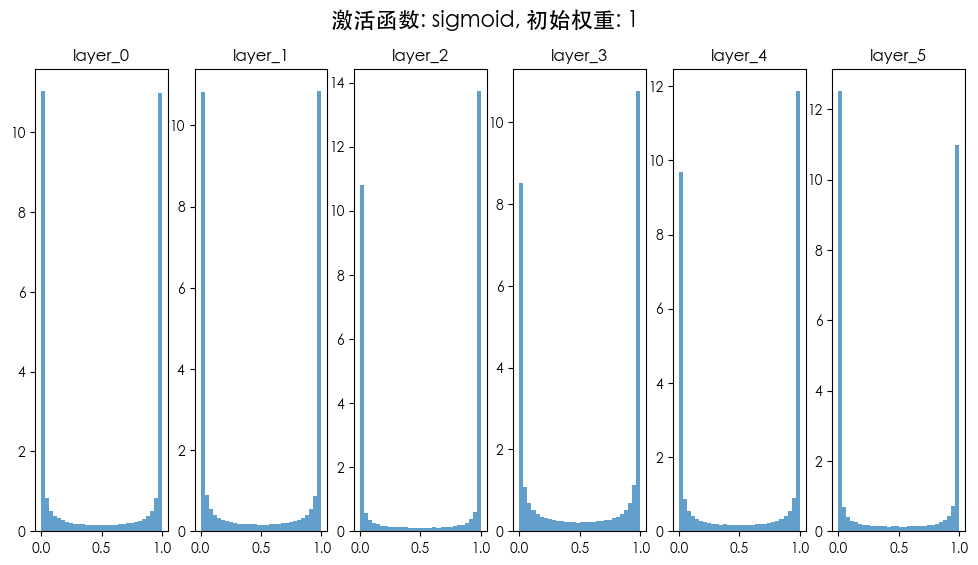

In [4]:
plot_activation_distribution(hidden_layer_size_list, weight_scale=1)

使用的sigmoid
函数是S型函数，随着输出不断地靠近0（或者靠近1），它的导数的值逐渐接
近0。因此，偏向0和1的数据分布会造成反向传播中梯度的值不断变小，最
后消失。这个问题称为梯度消失（gradient vanishing）。层次加深的深度学习
中，梯度消失的问题可能会更加严重。

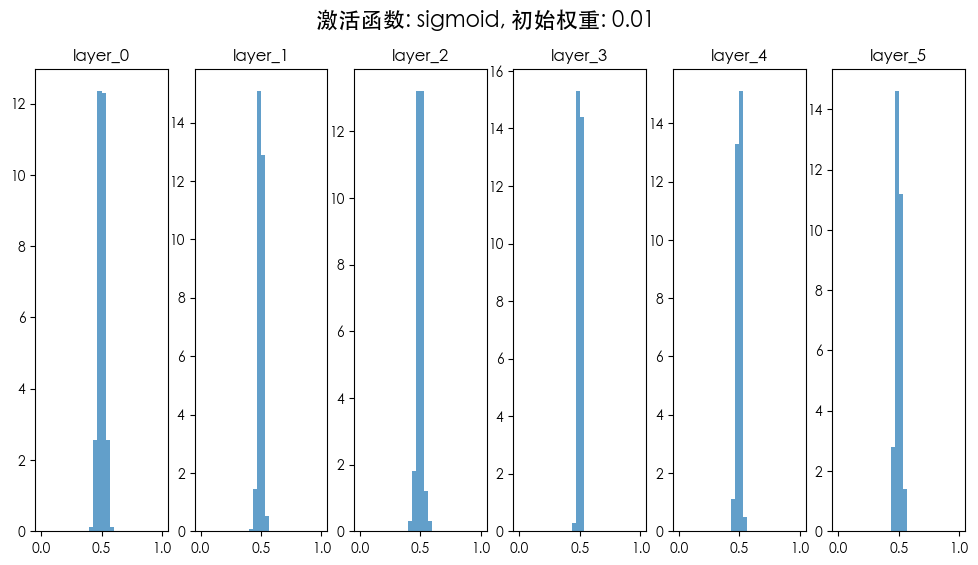

In [5]:
plot_activation_distribution(hidden_layer_size_list, weight_scale=0.01)

使用标准差为0.01的高斯分布时, 各层的激活值的分布集中在0.5附近的分布。因为不像刚才的例子那样偏向0和1，所以不会发生梯度消失的问题。但是，激活值的分布有所偏向，说明在表现力上会有很大问题。为什么这么说呢？因为如果有多个神经元都输出几乎相同的值，那它们就没有存在的意义了。比如，如果100个神经元都输出几乎相同的值，那么也可以由1个神经元来表达基本相同的事情。因此，激活值在分布上有所偏向会出现“表现力受限”的问题。

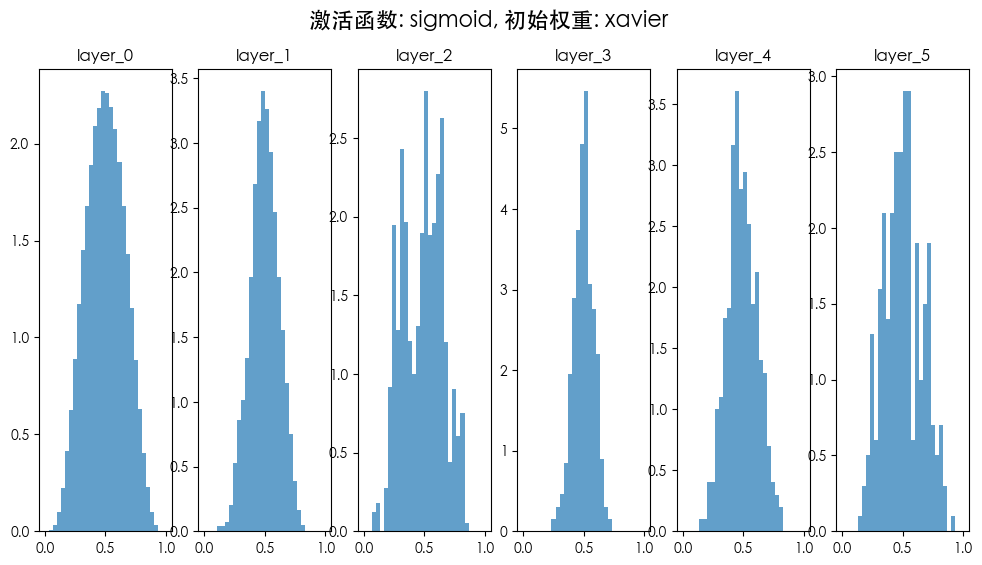

In [6]:
plot_activation_distribution(hidden_layer_size_list, weight_scale='xavier')

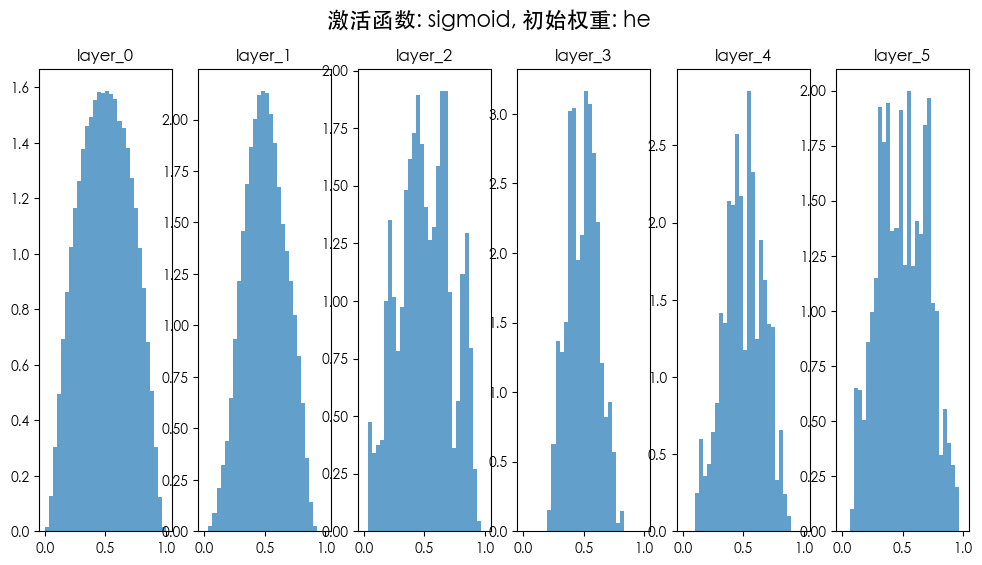

In [7]:
plot_activation_distribution(hidden_layer_size_list, weight_scale='he')

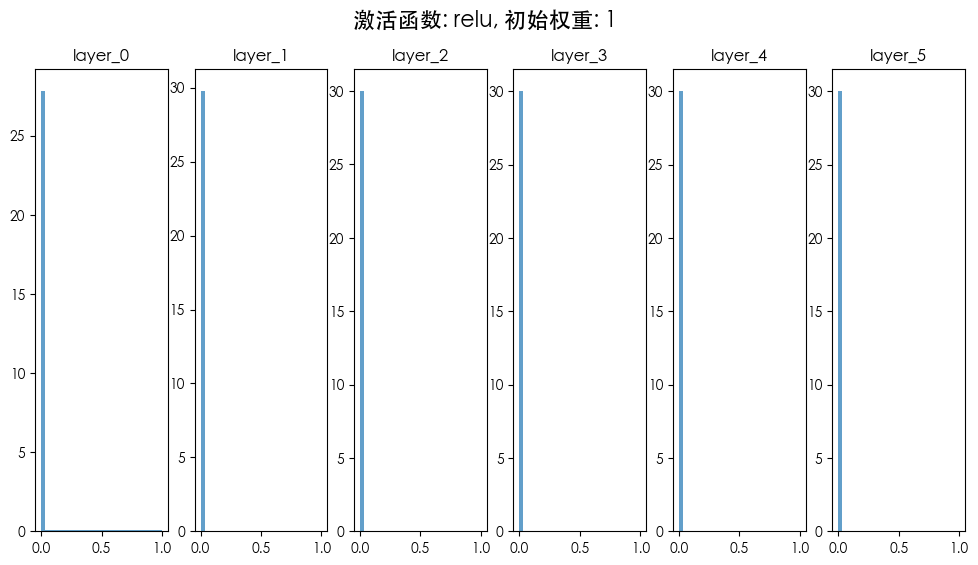

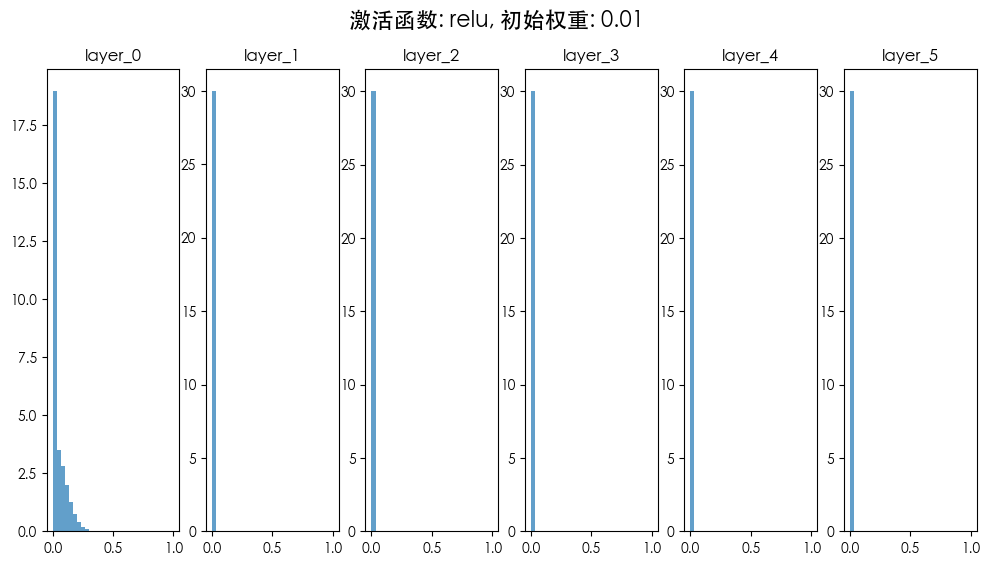

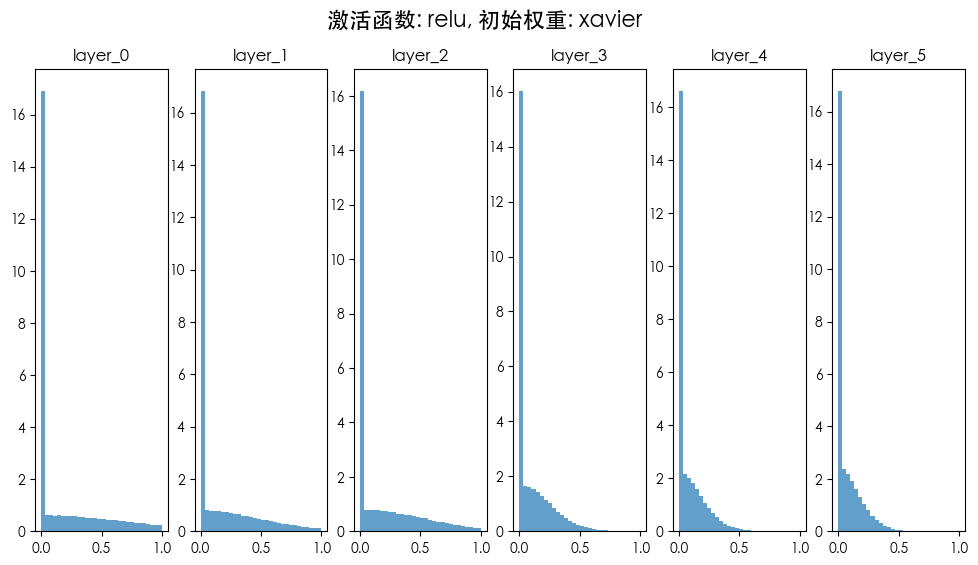

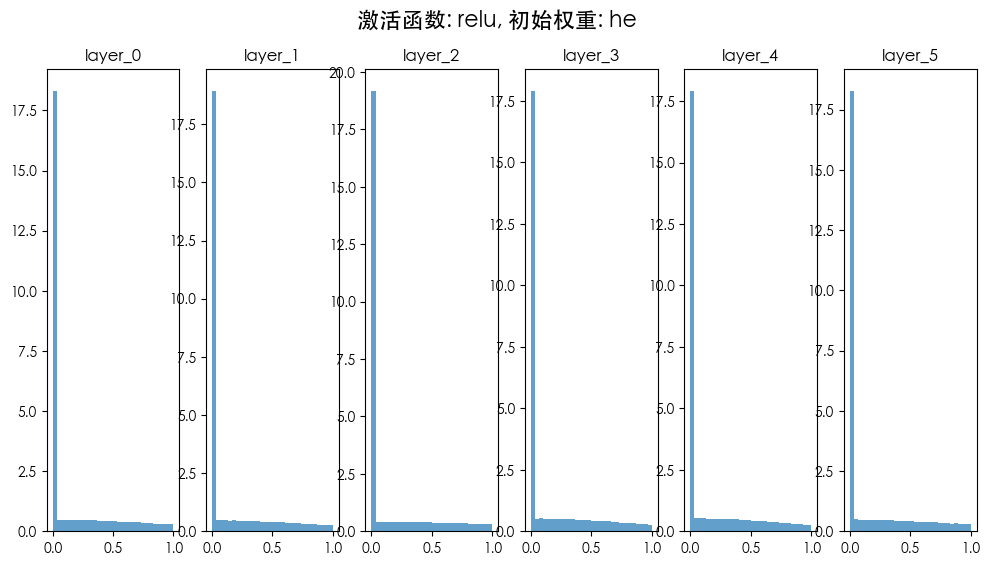

In [8]:
plot_activation_distribution(hidden_layer_size_list, activation_mod="relu", weight_scale=1)
plot_activation_distribution(hidden_layer_size_list, activation_mod="relu", weight_scale=0.01)
plot_activation_distribution(hidden_layer_size_list, activation_mod="relu", weight_scale="xavier")
plot_activation_distribution(hidden_layer_size_list, activation_mod="relu", weight_scale="he")

当“std = 0.01”时，各层的激活值非常小 A。神经网络上传递的是非常小的值，说明逆向传播时权重的梯度也同样很小。这是很严重的问题，实际上学习基本上没有进展。

接下来是初始值为Xavier初始值时的结果。在这种情况下，随着层的加深，
偏向一点点变大。实际上，层加深后，激活值的偏向变大，学习时会出现梯
度消失的问题。而当初始值为He初始值时，各层中分布的广度相同。由于
即便层加深，数据的广度也能保持不变，因此逆向传播时，也会传递合适的值。
总结一下，当激活函数使用ReLU时，权重初始值使用He初始值，当
激活函数为sigmoid或tanh等S型曲线函数时，初始值使用Xavier初始值。
这是目前的最佳实践。
